## project setup
here we define the modules that we are going to utilize this is to ensre the modules can easily be reused all through our project so ensure to load this cell at the begining 

In [8]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import seaborn as sns

from scipy import stats 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

In [9]:
import os
import pandas as pd

# 1. Check where Python is currently looking
current_dir = os.getcwd()
print(f"Current Working Directory: {current_dir}\n")

# 2. List everything in the current directory
print("Contents of current directory:", os.listdir())

# 3. Check inside the 'data' and 'data/raw' folders if they exist
if os.path.exists("data"):
    print("Contents of 'data' folder:", os.listdir("data"))
    if os.path.exists("data/raw"):
        print("Contents of 'data/raw' folder:", os.listdir("data/raw"))
else:
    print("\n⚠️ The 'data' folder does NOT exist in your current directory.")

# 4. Automatically search for the file in all subfolders
print("\n🔍 Searching for your CSV files...")
target_file1 = "ma3route_crashes_algorithmcode.csv"
target_file2 = "ma3route_crashes_manualcode.csv"

for root, dirs, files in os.walk(current_dir):
    if target_file1 in files:
        print(f"✅ Found algorithm dataset at: {os.path.join(root, target_file1)}")
    if target_file2 in files:
        print(f"✅ Found manual dataset at: {os.path.join(root, target_file2)}")

Current Working Directory: /home/fidel/Documents/Road-accident-blackspot-detection-Project

Contents of current directory: ['config', 'src', 'data', 'app', 'README.md', '.git', 'requirements.txt', 'notebooks']
Contents of 'data' folder: ['raw']
Contents of 'data/raw' folder: ['ma3route_crashes_manualcode.csv', 'ma3route_crashes_cleaned.csv', 'ma3route_crashes_algorithmcode.csv']

🔍 Searching for your CSV files...
✅ Found algorithm dataset at: /home/fidel/Documents/Road-accident-blackspot-detection-Project/data/raw/ma3route_crashes_algorithmcode.csv
✅ Found manual dataset at: /home/fidel/Documents/Road-accident-blackspot-detection-Project/data/raw/ma3route_crashes_manualcode.csv


In [10]:
#uncomment then run once then comment again
#import os
#os.getcwd()


In [11]:
#uncomment then run once then comment again
#os.chdir('/home/fidel/Documents/Road-accident-blackspot-detection-Project')
#os.getcwd()

## Data loading 
here we are using two datasets one being the manual one that is simple and a bit smallere this is to leverage the testings as we build 

In [12]:
# if having issues with the file path then uncomment this bello codes to get to know how to get to read the datasers with no dificulties

import os 

# print(os.listdir())
#print(os.getcwd())
algorithmDataset = pd.read_csv("data/raw/ma3route_crashes_algorithmcode.csv")

manualDataset = pd.read_csv("data/raw/ma3route_crashes_manualcode.csv")

print(f"Algorithm dataset shape: {algorithmDataset.shape}")
print(f"Manual dataset shape: {manualDataset.shape}")

Algorithm dataset shape: (31064, 10)
Manual dataset shape: (2595, 10)


## Dataset structural accessment 
here we get to see the structure and the types of the datasets that we are to utilize 

In [13]:
Attributes = algorithmDataset.columns.tolist()
Attributes

['crash_id',
 'crash_datetime',
 'crash_date',
 'latitude',
 'longitude',
 'n_crash_reports',
 'contains_fatality_words',
 'contains_pedestrian_words',
 'contains_matatu_words',
 'contains_motorcycle_words']

In [14]:
structureData = pd.DataFrame({
    "columns" : algorithmDataset.columns,
    "data_type" : algorithmDataset.dtypes.values,
})
structureData

,columns,data_type
0,crash_id,int64
1,crash_datetime,str
2,crash_date,str
3,latitude,float64
4,longitude,float64
5,n_crash_reports,int64
6,contains_fatality_words,int64
7,contains_pedestrian_words,int64
8,contains_matatu_words,int64
9,contains_motorcycle_words,int64


## Datatype assessment


In [15]:
algorithmDataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 31064 entries, 0 to 31063
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   crash_id                   31064 non-null  int64  
 1   crash_datetime             31064 non-null  str    
 2   crash_date                 31064 non-null  str    
 3   latitude                   31064 non-null  float64
 4   longitude                  31064 non-null  float64
 5   n_crash_reports            31064 non-null  int64  
 6   contains_fatality_words    31064 non-null  int64  
 7   contains_pedestrian_words  31064 non-null  int64  
 8   contains_matatu_words      31064 non-null  int64  
 9   contains_motorcycle_words  31064 non-null  int64  
dtypes: float64(2), int64(6), str(2)
memory usage: 2.4 MB


## Missing values assessment

crash_id                     0
crash_datetime               0
crash_date                   0
latitude                     0
longitude                    0
n_crash_reports              0
contains_fatality_words      0
contains_pedestrian_words    0
contains_matatu_words        0
contains_motorcycle_words    0
dtype: int64
Total missing values in the dataset: 0


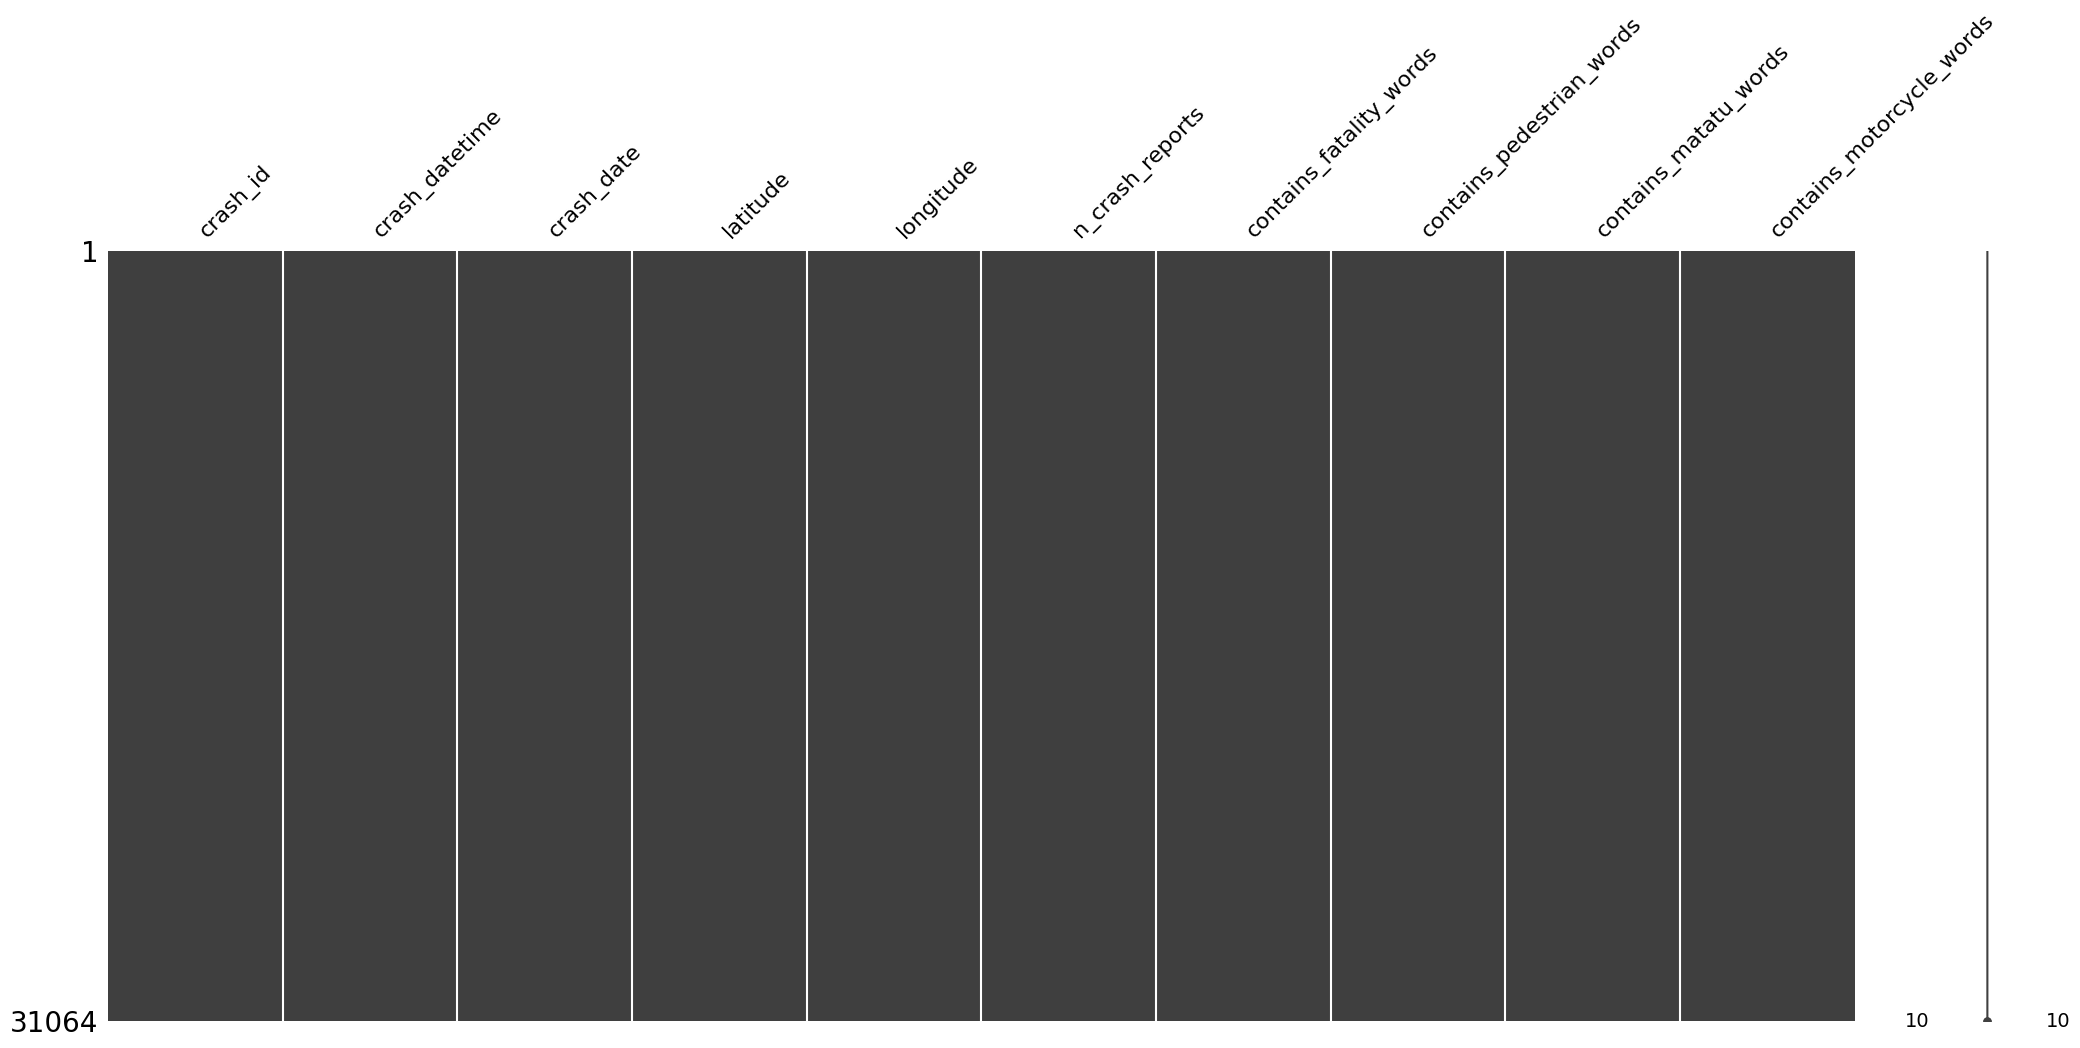

In [16]:
missing = algorithmDataset.isnull().sum()
print(missing)
msno.matrix(algorithmDataset)
total_missing = algorithmDataset.isnull().sum().sum()
print(f"Total missing values in the dataset: {total_missing}")


<Axes: >

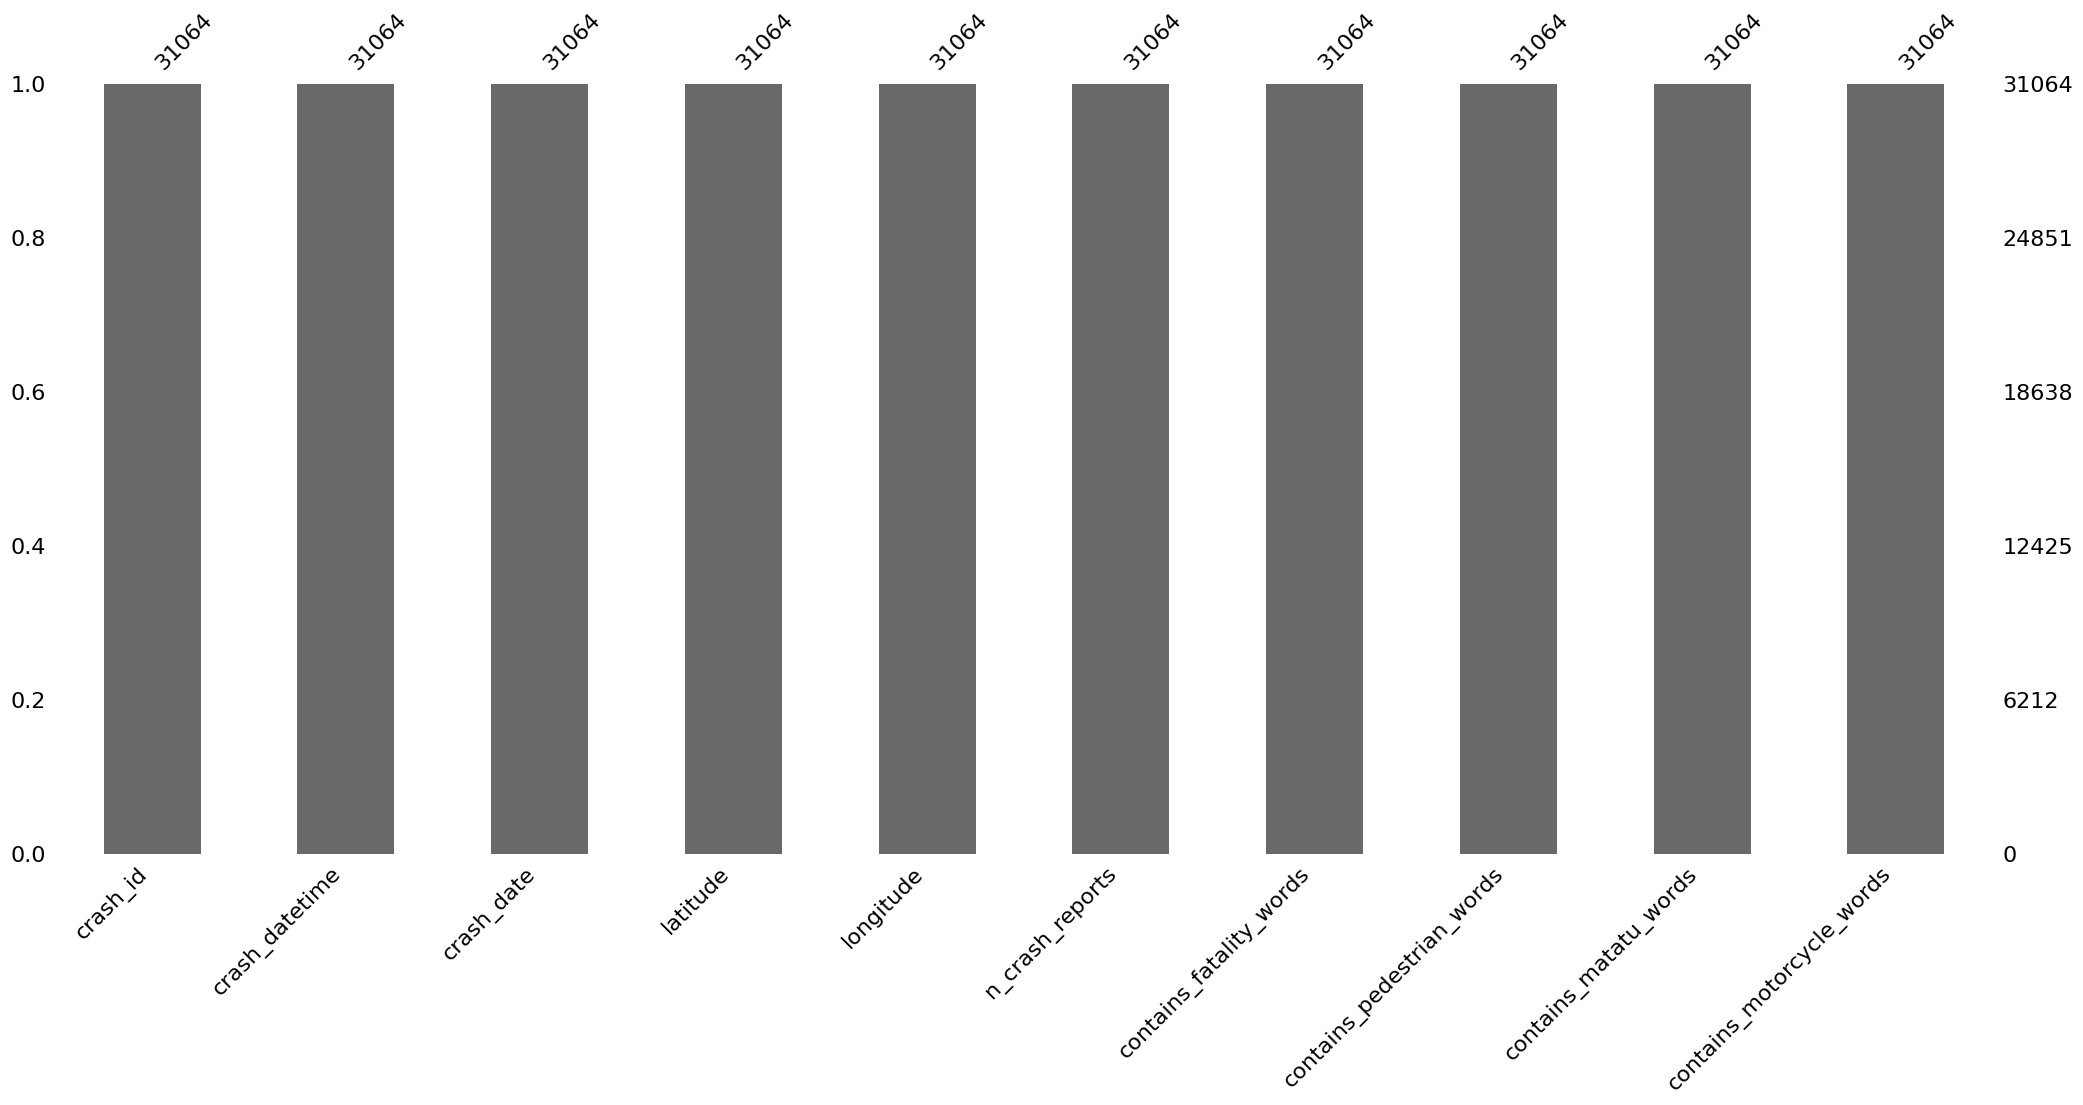

In [17]:
msno.bar(algorithmDataset)

## Duplicate assessment

In [18]:
algorithmDataset.duplicated().sum()

np.int64(0)